In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
fineli_data = pd.read_csv("../Datasets/fineli.csv", sep=";")
fineli_data = fineli_data[["name", "energia, laskennallinen (kJ)", "rasva (g)", "hiilihydraatti imeytyvä (g)", "proteiini (g)", "alkoholi (g)"]]

fineli_data.head()

,name,"energia, laskennallinen (kJ)",rasva (g),hiilihydraatti imeytyvä (g),proteiini (g),alkoholi (g)
0,Ahven,345,0.7,0,18.8,0
1,"Ahven, leivitetty, paistettu",660,6.5,4.7,19.9,0
2,"Ahven, paistettu, ei korppujauhoja",600,6.8,<0.1,20.5,0
3,"Ahven, paistettu voissa, ei korppujauhoja",595,7.3,<0.1,19.1,0
4,"Ahvenet foliossa, voissa",496,4.1,0.6,19.5,0


In [3]:
CQP_1 = pd.read_csv("../Datasets/CQP1.csv", sep=";")
CQP_2 = pd.read_csv("../Datasets/CQP2.csv", sep=";")
CQP_3 = pd.read_csv("../Datasets/CQP3.csv", sep=";")
CQP_4 = pd.read_csv("../Datasets/CQP4.csv", sep=";")
CQP_5 = pd.read_csv("../Datasets/CQP5.csv", sep=";")
CQP_6 = pd.read_csv("../Datasets/CQP6.csv", sep=";")
CQP_7 = pd.read_csv("../Datasets/CQP7.csv", sep=";")
CQP_8 = pd.read_csv("../Datasets/CQP8.csv", sep=";")

CQP = pd.concat([CQP_1, CQP_2, CQP_3, CQP_4, CQP_5, CQP_6, CQP_7, CQP_8])
CQP = CQP[["word", "text_thread_id"]]

CQP.head()

,word,text_thread_id
0,Σ,Σ
1,hapankaali,16796146
2,hedelmä,17969829
3,hampurilainen,18191211
4,hedelmä,17254127


Removing duplicates from CQP data. This list will be used as a filter for the Fineli dataframe

In [4]:
food_filter = CQP["word"].dropna().str.lower().drop_duplicates().tolist()
food_filter.remove('σ')

print(food_filter)
print(len(food_filter))

['hapankaali', 'hedelmä', 'hampurilainen', 'ananas', 'banaani', 'ahven', 'hauki', 'hernekeitto', 'bataatti', 'chili', 'broileri', 'hillo', 'herne', 'appelsiini', 'hiiva', 'anjovis', 'avokado', 'ateriankorvike', 'etana', 'hunaja', 'hummeri', 'ahvenet', 'hoki', 'borssikeitto', 'hirssi', 'herkkusieni', 'haaparousku', 'grillimakkara', 'creme', 'basilika', 'auringonkukansiemen', 'aromisuola', 'hirvenliha', 'donitsi', 'blini', 'ankerias', 'herkkutatti', 'granaattiomena', 'graavilohi', 'fruktoosi', 'etikkakurkku', 'energiajuoma', 'elovena', 'chiansiemen', 'broilerikeitto', 'broilerifilee', 'aprikoosi', 'hummus', 'herkkusienikeitto', 'booli', 'amarantti', 'hedelmäsalaatti', 'greippi', 'hirvenpaisti', 'hillosipulisäilyke', 'herneenverso', 'heraproteiinikonsentraatti', 'herajauhe', 'hedelmäjuoma', 'hedelmähillo', 'hasselpähkinäjuoma', 'hapanlohko', 'hapankurkku', 'hapankorppu', 'hapankaalikeitto', 'hampunsiemen', 'guava', 'fenkolikeitto', 'fenkoli', 'etikkasienisäilyke', 'etikkapunajuuri', 'erik

Defining similarity based on nutritional vectors

In [5]:
from sklearn.preprocessing import StandardScaler

fineli_data["name"] = fineli_data["name"].str.lower()

filtered_df = fineli_data[fineli_data["name"].isin(food_filter)].copy()

features = ["energia, laskennallinen (kJ)", "rasva (g)", "hiilihydraatti imeytyvä (g)", "proteiini (g)", "alkoholi (g)"]
X = filtered_df[features].copy()

for col in X.columns:
    X[col] = X[col].astype(str).str.replace("<", "", regex=False)

X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna()

filtered_df = filtered_df.loc[X.index]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Cosine similariy

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X_scaled)

sim_df = pd.DataFrame(
    similarity_matrix,
    index=filtered_df["name"],
    columns=filtered_df["name"]
)

Creating edges based on similarity threshold

In [33]:
threshold = 0.85

edges = []

names = filtered_df["name"].tolist()

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        if similarity_matrix[i, j] > threshold:
            edges.append((names[i], names[j]))

Creating graph for data

In [34]:
G = nx.Graph()
G.add_nodes_from(names)
G.add_edges_from(edges)


Computing number of nodes and edges, average degree, clustering coefficient, density and diameter and average path length

In [35]:
print(f"Nodes: {len(G.nodes)}")
print(f"Edges: {len(G.edges)}")

average_degree = sum(dict(G.degree()).values()) / len(G)

print(f"Average degree: {round(average_degree)}")

average_clustering_coefficient = nx.average_clustering(G)
print(f"Average clustering coefficient: {round(average_clustering_coefficient, 5)}")

density = nx.density(G)
largest_connected_component = max(nx.connected_components(G), key=len)
G_sub = G.subgraph(largest_connected_component)
diameter = nx.diameter(G_sub)

print(f"Density: {round(density, 4)}")
print(f"Diameter: ", diameter)

average_path_length = nx.average_shortest_path_length(G_sub)
print(f"Average shortest path length: {round(average_path_length, 2)}")



Nodes: 223
Edges: 5722
Average degree: 51
Average clustering coefficient: 0.85844
Density: 0.2312
Diameter:  10
Average shortest path length: 3.8


Visualizising the similarity network

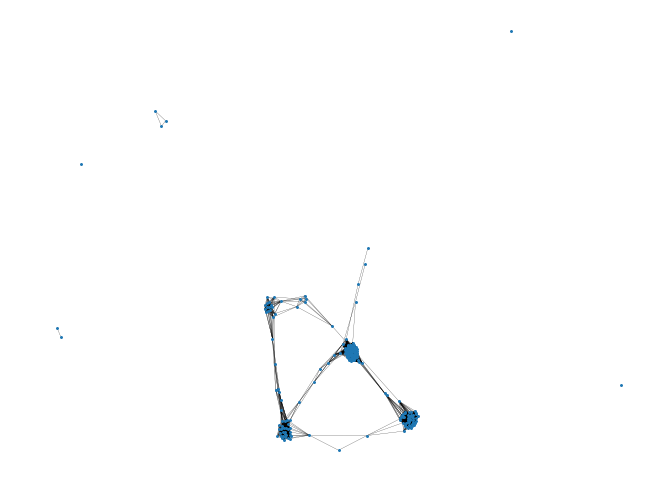

In [36]:
nx.draw_spring(G, node_size=1.3, width=0.15)
plt.show()

Computing degree centrality, betweenness centrality, closeness centrality and eigenvector centrality 

In [40]:
dc = nx.degree_centrality(G)
bc = nx.betweenness_centrality(G)
cc = nx.closeness_centrality(G)
ec = nx.eigenvector_centrality(G)

print(dc)
print(bc)
print(cc)
print(ec)

{'ahven': 0.16666666666666666, 'ananassalsa': 0.4144144144144144, 'anjovis': 0.08558558558558559, 'ankerias': 0.02702702702702703, 'appelsiinimarmeladi': 0.08108108108108109, 'appelsiiniriisi': 0.24324324324324323, 'auringonkukkaöljy': 0.07207207207207207, 'avokadopasta': 0.013513513513513514, 'avokadoöljy': 0.07207207207207207, 'bambunverso': 0.4099099099099099, 'bearnaisekastike': 0.0, 'broilerikeitto': 0.4009009009009009, 'broilerisuikale': 0.1981981981981982, 'chiansiemen': 0.02702702702702703, 'etana': 0.16216216216216217, 'etikkapunajuuri': 0.4189189189189189, 'etikkasienisäilyke': 0.42342342342342343, 'guava': 0.4189189189189189, 'haaparousku': 0.4099099099099099, 'hapankaali': 0.4189189189189189, 'hapankorppu': 0.11711711711711711, 'hauki': 0.16216216216216217, 'heraproteiinikonsentraatti': 0.06306306306306306, 'herkkusieni': 0.40540540540540543, 'herkkusienikeitto': 0.4009009009009009, 'herkkutatti': 0.4099099099099099, 'herneenverso': 0.3963963963963964, 'hillosipulisäilyke':

Identifying most influential food items

In [65]:
top_20_dc = sorted(dc.items(), key=lambda x: x[1], reverse=True)[:20]
top_20_bc = sorted(bc.items(), key=lambda x: x[1], reverse=True)[:20]
top_20_cc = sorted(cc.items(), key=lambda x: x[1], reverse=True)[:20]
top_20_ec = sorted(ec.items(), key=lambda x: x[1], reverse=True)[:20]

print("TOP 20 FOODS\n")
print(f"Highest degree centrality foods: {top_20_dc}\n")
print(f"Highest betweennes centrality foods: {top_20_bc}\n")
print(f"Highest closeness centrsality foods: {top_20_cc}\n")
print(f"Highest eigenvector centrlity foods: {top_20_ec}\n\n")

dc_names, dc_values = zip(*top_20_dc)   
bc_names, bc_values = zip(*top_20_bc)
cc_names, cc_values = zip(*top_20_cc)
ec_names, ec_values = zip(*top_20_ec)

print("TOP 3 FOODS FROM EACH MEASURE CATEGORY\n")
print(f"Top 3 foods with highest degree centrality: {dc_names[:3]}\n")
print(f"Top 3 foods with highest betweennes centrality: {bc_names[:3]}\n")
print(f"Top 3 foods with highest closeness centrality: {cc_names[:3]}\n")
print(f"Top 3 foods with highest eigenvector centrality: {ec_names[:3]}")


TOP 20 FOODS

Highest degree centrality foods: [('etikkasienisäilyke', 0.42342342342342343), ('linssikeitto', 0.42342342342342343), ('minestronekeitto', 0.42342342342342343), ('punakaali', 0.42342342342342343), ('etikkapunajuuri', 0.4189189189189189), ('guava', 0.4189189189189189), ('hapankaali', 0.4189189189189189), ('karpalo', 0.4189189189189189), ('karviainen', 0.4189189189189189), ('kesäkeitto', 0.4189189189189189), ('kukkakaalimuhennos', 0.4189189189189189), ('lanttu', 0.4189189189189189), ('munakoiso', 0.4189189189189189), ('mustajuuri', 0.4189189189189189), ('palsternakka', 0.4189189189189189), ('porkkana', 0.4189189189189189), ('porkkanasurvos', 0.4189189189189189), ('raparperi', 0.4189189189189189), ('tomaatti', 0.4189189189189189), ('tomaattimurska', 0.4189189189189189)]

Highest betweennes centrality foods: [('porokeitto', 0.15837706256305661), ('puolukkahillo', 0.117455393203218), ('vesikastanja', 0.10971330561279492), ('mämmi', 0.10309882250159799), ('omenahillo', 0.102355